### **Algoritmo de Ford-Fulkerson**

El algoritmo de Ford-Fulkerson busca encontrar el **flujo máximo** en una red de flujo, explorando caminos desde el nodo fuente al sumidero donde se pueda enviar más flujo, y aumentando gradualmente el flujo total en la red.

**Proceso**:

1. **Inicialización**:
   Comienza con un flujo de 0 en todas las aristas. La capacidad total disponible en cada arista se representa como una "red residual" que irá cambiando conforme se envíe flujo a través de la red.

2. **Búsqueda de Caminos Aumentantes**:
   Se busca un **camino aumentante** desde la fuente al sumidero. Un camino aumentante es un camino en el que todas las aristas tienen capacidad residual disponible. Para encontrar estos caminos, se puede utilizar un algoritmo como DFS (Búsqueda en profundidad) o BFS (Búsqueda en anchura).

3. **Aumentar el Flujo**:
   Una vez encontrado un camino aumentante, se calcula cuánta capacidad puede ser utilizada para aumentar el flujo en ese camino (el flujo está limitado por la arista con menor capacidad en el camino). Aumenta el flujo en todas las aristas de ese camino en función de la capacidad disponible.

4. **Actualizar la Red Residual**:
   Después de enviar flujo por el camino aumentante, actualiza las **capacidades residuales** de las aristas: disminuye la capacidad en las direcciones del flujo, y añade capacidad en la dirección inversa (para poder reducir el flujo si es necesario en pasos futuros).

5. **Repetir el Proceso**:
   El algoritmo continúa buscando y enviando flujo por caminos aumentantes hasta que ya no es posible encontrar más caminos con capacidad residual. En ese punto, el flujo total acumulado será el **flujo máximo**.

Ford-Fulkerson explora todos los posibles caminos desde la fuente al sumidero, incrementando el flujo paso a paso, y manteniendo actualizada una red residual. Al final, el flujo máximo es alcanzado cuando no queda capacidad residual en ningún camino que conecte la fuente con el sumidero.

### **Flujo Máximo**
El flujo total que se puede enviar desde la fuente hasta el sumidero sin violar las capacidades de las aristas es el resultado final del algoritmo.



In [1]:
def bfs(graph, s, t, parent):
    visited = [False] * len(graph)
    queue = []
    queue.append(s)
    visited[s] = True
    while queue:
        u = queue.pop(0)
        for ind, val in enumerate(graph[u]):
            if visited[ind] == False and val > 0:
                queue.append(ind)
                visited[ind] = True
                parent[ind] = u
                
    return True if visited[t] else False

In [2]:
def fold_fulkerson(graph, source, sink):
    parent = [-1] * len(graph)
    max_flow = 0
    while bfs(graph, source, sink, parent):
        path_flow = float("Inf")
        s = sink
        while s != source:
            path_flow = min(path_flow, graph[parent[s]][s])
            s = parent[s]

        max_flow += path_flow
        v = sink
        
        while v != source:
            u = parent[v]
            graph[u][v] -= path_flow
            graph[v][u] += path_flow
            v = parent[v]
    return max_flow

In [3]:
Graph = [[0, 6, 4, 1, 0, 0],
         [0, 0, 0, 4, 0, 0],
         [0, 0, 3, 1, 3, 0],
         [0, 0, 0, 0, 4, 0],
         [0, 0, 0, 0, 0, 4],
         [0, 0, 0, 0, 0, 9],
         [0, 0, 0, 0, 0, 0]]
         

source = 0
sink = 5

print("El flujo máximo es: ", fold_fulkerson(Graph, source, sink))

El flujo máximo es:  4


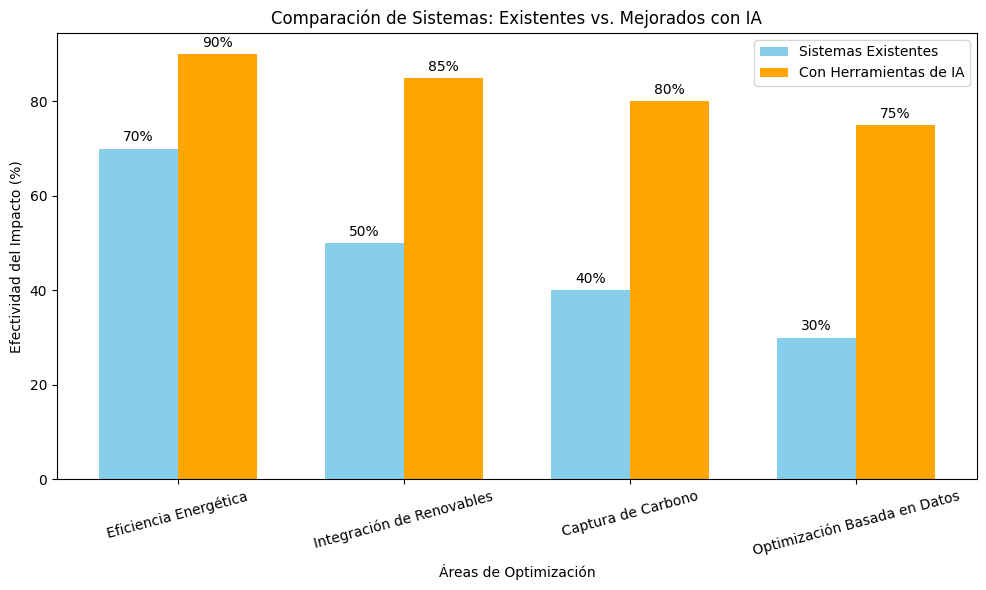

In [4]:
import matplotlib.pyplot as plt
import numpy as np

categorias = ['Eficiencia Energética', 'Integración de Renovables', 'Captura de Carbono', 'Optimización Basada en Datos']
impacto_existente = [70, 50, 40, 30]  
impacto_potencial = [90, 85, 80, 75]  

x = np.arange(len(categorias))  # Ubicación en el eje x

# Crear el gráfico de barras
ancho = 0.35  # Ancho de las barras
fig, ax = plt.subplots(figsize=(10, 6))

# Barras para los sistemas existentes y el potencial mejorado con IA
barras1 = ax.bar(x - ancho/2, impacto_existente, ancho, label='Sistemas Existentes', color='skyblue')
barras2 = ax.bar(x + ancho/2, impacto_potencial, ancho, label='Con Herramientas de IA', color='orange')

# Etiquetas y formato
ax.set_xlabel('Áreas de Optimización')
ax.set_ylabel('Efectividad del Impacto (%)')
ax.set_title('Comparación de Sistemas: Existentes vs. Mejorados con IA')
ax.set_xticks(x)
ax.set_xticklabels(categorias, rotation=15)
ax.legend()

# Añadir anotaciones de valores en las barras
for barra in barras1 + barras2:
    altura = barra.get_height()
    ax.annotate(f'{altura}%', xy=(barra.get_x() + barra.get_width()/2, altura),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom')

plt.tight_layout()
plt.show()
